# YOLO+SAM

In [ ]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/12

In [ ]:
import ultralytics
from IPython.display import display, Image
from roboflow import Roboflow
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
ultralytics.checks()

Ultralytics 8.3.155 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.7/107.7 GB disk)


In [ ]:
first_run = True
if first_run:
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-k6nllfe6
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-k6nllfe6
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=895f05ce81faa9bf4f77675a23932f1f1200e45ab9e99f0734bc4dba560051c3
  Stored in directory: /tmp/pip-ephem-wheel-cache-te08u__v/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything
--2025-06-16 23:55:08--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.238.176.44, 18.238.176.115, 18.238.176.19, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.23

In [ ]:
!yolo predict model=yolov8n.pt source='./imagen.jpg'

100% 6.25M/6.25M [00:00<00:00, 52.1MB/s]
Ultralytics 8.3.155 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/imagen.jpg: 384x640 19 persons, 12 cars, 1 bus, 1 truck, 380.7ms
Speed: 13.8ms preprocess, 380.7ms inference, 33.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


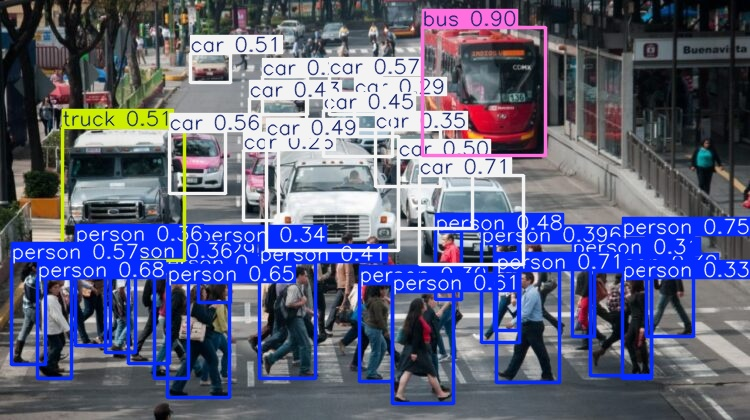

In [ ]:
Image(filename='runs/detect/predict/imagen.jpg', height=600)

In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
results = model.predict(source='./imagen.jpg', conf=0.25)


image 1/1 /content/imagen.jpg: 384x640 19 persons, 12 cars, 1 bus, 1 truck, 188.6ms
Speed: 6.1ms preprocess, 188.6ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

# Extraer Bounding box

In [ ]:
for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs

bbox=boxes.xyxy.tolist()[0]

In [ ]:
bbox

[422.51959228515625, 27.009307861328125, 545.0697631835938, 155.96377563476562]

In [ ]:
image = cv2.cvtColor(cv2.imread('./imagen.jpg'), cv2.COLOR_BGR2RGB)

In [ ]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
predictor = SamPredictor(sam)
predictor.set_image(image)

In [ ]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

In [ ]:
input_box = np.array(bbox)

# Convertir la bounding box a segmentation mask

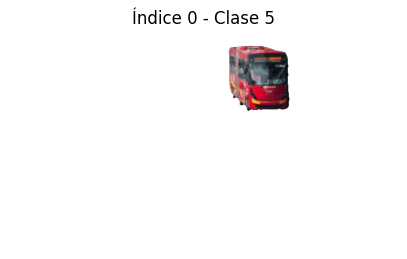

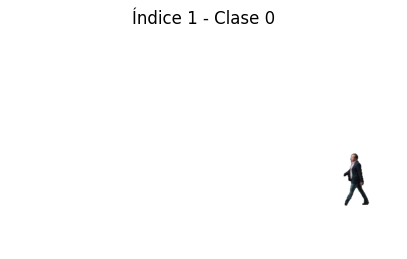

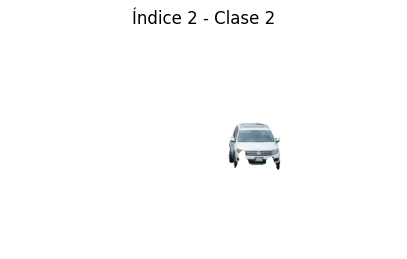

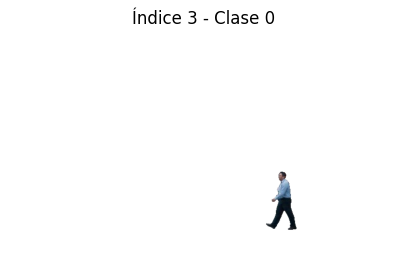

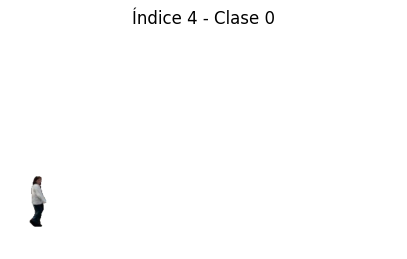

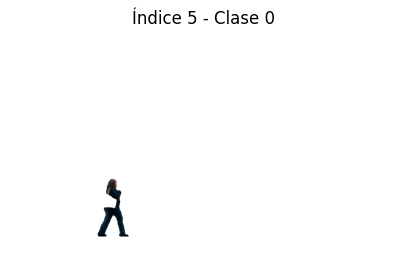

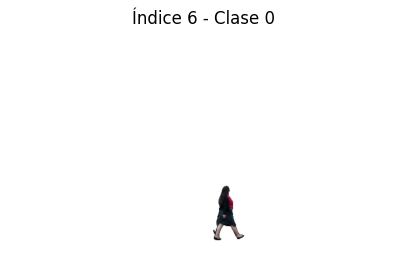

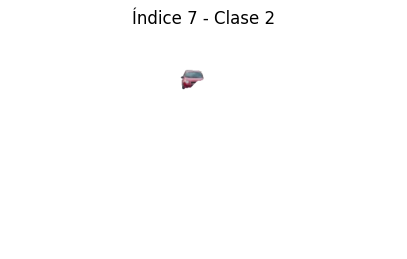

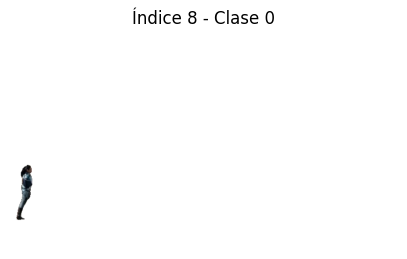

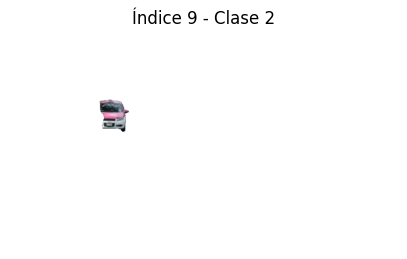

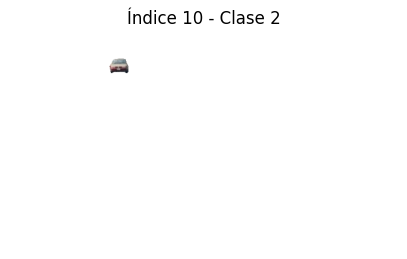

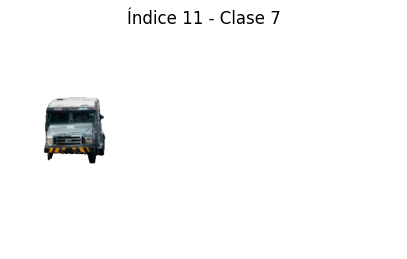

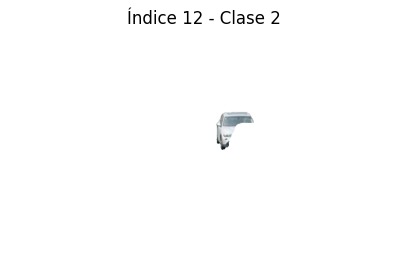

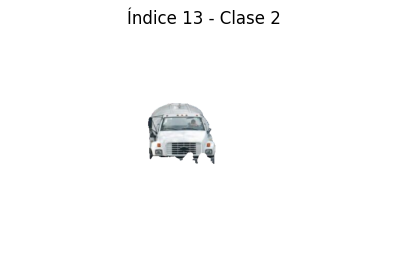

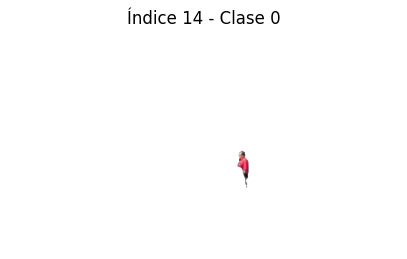

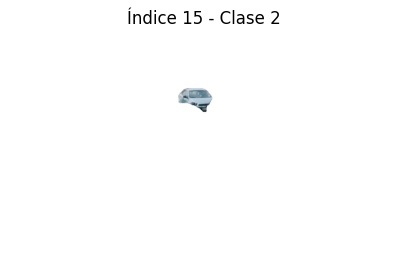

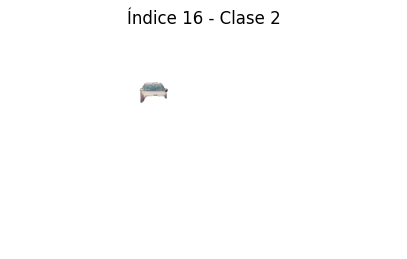

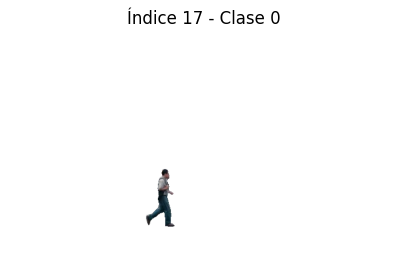

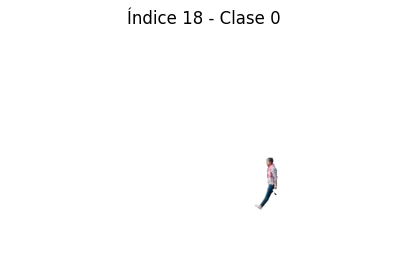

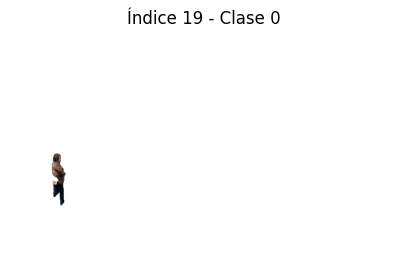

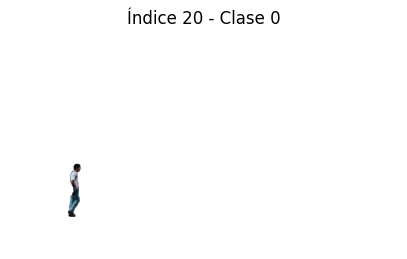

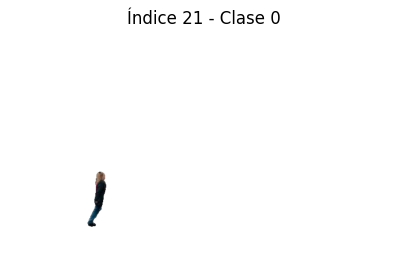

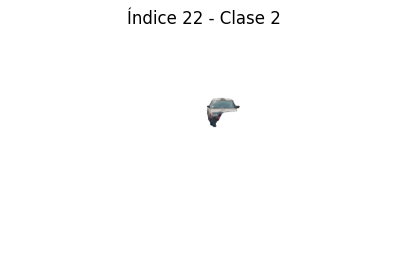

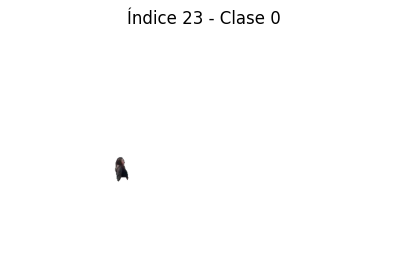

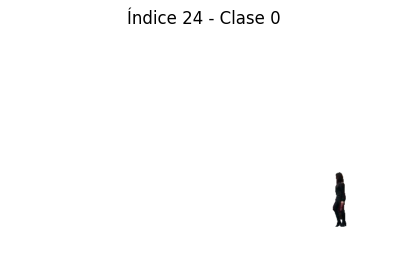

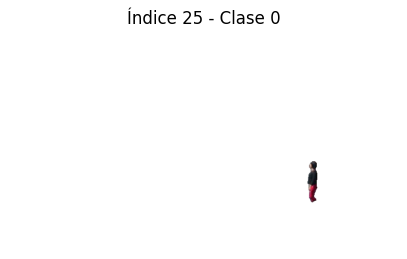

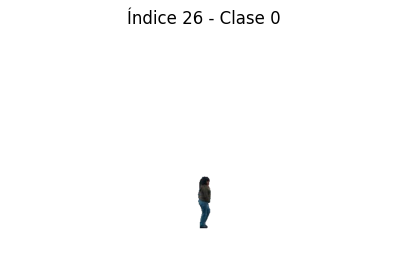

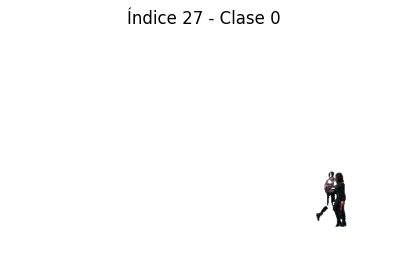

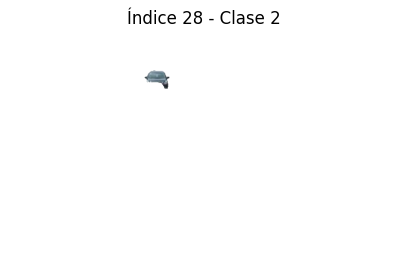

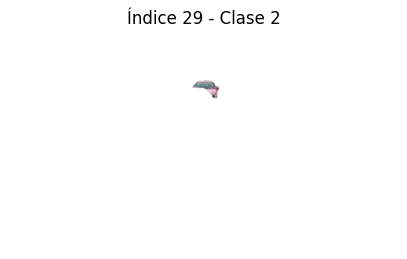

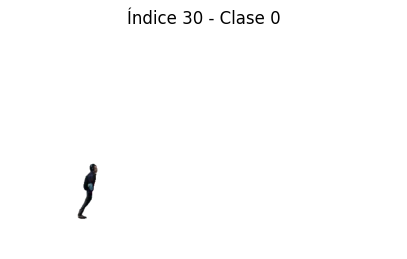

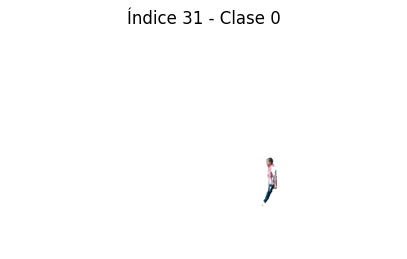

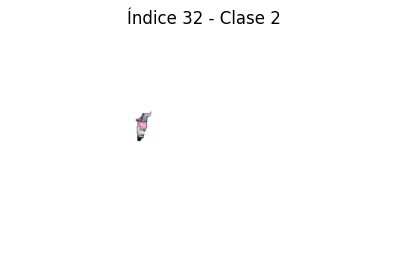

In [ ]:
# Mostrar todas las máscaras generadas
for i, box in enumerate(boxes):
    input_box = box
    masks, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box[None, :],
        multimask_output=False,
    )
    binary_mask = (masks[0] > 0.5).astype(np.uint8)

    white_background = np.ones_like(image) * 255
    new_image = white_background * (1 - binary_mask[..., None]) + image * binary_mask[..., None]

    plt.figure(figsize=(5, 5))
    plt.imshow(new_image.astype(np.uint8))
    plt.title(f"Índice {i} - Clase {clases[i]}")
    plt.axis('off')
    plt.show()


In [ ]:
indice = 0
input_box = boxes[indice]

# Volver a segmentar el seleccionado
masks, _, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)
segmentation_mask = masks[0]
binary_mask = (segmentation_mask > 0.5).astype(np.uint8)


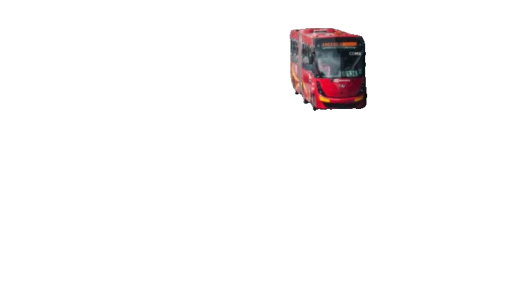

In [ ]:
segmentation_mask = masks[0]
binary_mask = np.where(segmentation_mask > 0.5, 1, 0)

white_background = np.ones_like(image) * 255

new_image = white_background * (1 - binary_mask[..., np.newaxis]) + image * binary_mask[..., np.newaxis]

plt.imshow(new_image.astype(np.uint8))
plt.axis('off')
plt.show()


# Midas

In [ ]:
pip install timm

In [ ]:
import cv2
import torch
import urllib.request

import matplotlib.pyplot as plt

In [ ]:
model_type = "DPT_Large"     # MiDaS v3 - Large     (highest accuracy, slowest inference speed)
#model_type = "DPT_Hybrid"   # MiDaS v3 - Hybrid    (medium accuracy, medium inference speed)
#model_type = "MiDaS_small"  # MiDaS v2.1 - Small   (lowest accuracy, highest inference speed)

midas = torch.hub.load("intel-isl/MiDaS", model_type)

You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Importing from timm.models.layers is deprecated, please import via timm.layers
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt
100%|██████████| 1.28G/1.28G [00:22<00:00, 60.8MB/s]


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
midas.to(device)
midas.eval()

DPTDepthModel(
  (pretrained): Module(
    (model): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_featur

In [ ]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [ ]:
img = cv2.imread('./imagen.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

In [ ]:
with torch.no_grad():
    prediction = midas(input_batch)

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output = prediction.cpu().numpy()

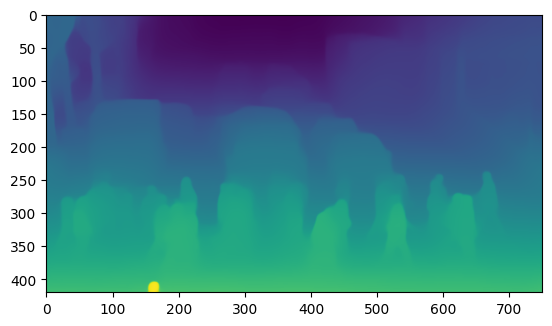

In [ ]:
plt.imshow(output)
# plt.show()

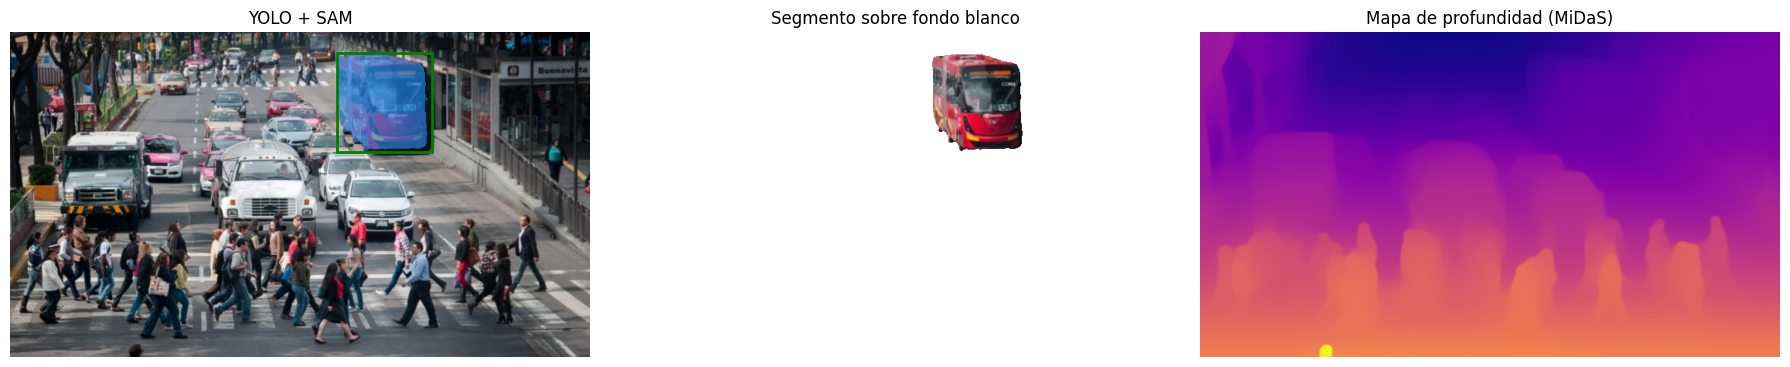

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(image)
show_mask(segmentation_mask, axs[0])
show_box(input_box, axs[0])
axs[0].set_title("YOLO + SAM")
axs[0].axis('off')

axs[1].imshow(new_image.astype(np.uint8))
axs[1].set_title("Segmento sobre fondo blanco")
axs[1].axis('off')

axs[2].imshow(output, cmap='plasma')
axs[2].set_title("Mapa de profundidad (MiDaS)")
axs[2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)
clases = results[0].boxes.cls.cpu().numpy().astype(int)
confianzas = results[0].boxes.conf.cpu().numpy()

registros = []

for i, (box, clase, conf) in enumerate(zip(boxes, clases, confianzas)):
    input_box = box
    masks, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box[None, :],
        multimask_output=False,
    )
    if masks is None or len(masks) == 0:
        continue

    segmentation_mask = masks[0]
    binary_mask = (segmentation_mask > 0.5).astype(np.uint8)

    if np.sum(binary_mask) == 0:
        continue

    profundidad_promedio = np.mean(output[binary_mask == 1])

    registros.append({
        'indice': i,
        'clase': clase,
        'confianza': float(conf),
        'bbox': input_box.tolist(),
        'profundidad_promedio': profundidad_promedio
    })

df = pd.DataFrame(registros)
print(df)
df.to_csv("analisis_segmentacion_profundidad.csv", index=False)



    indice  clase  confianza                  bbox  profundidad_promedio
0        0      5   0.897187   [422, 27, 545, 155]              7.924047
1        1      0   0.750057  [646, 235, 693, 336]             22.364937
2        2      2   0.714369  [419, 175, 523, 264]             17.928978
3        3      0   0.711387  [496, 270, 559, 382]             27.124058
4        4      0   0.681014    [37, 278, 71, 378]             26.533512
5        5      0   0.652167  [167, 282, 229, 397]             28.143637
6        6      0   0.613682  [392, 291, 453, 403]             28.480532
7        7      2   0.572304   [329, 75, 381, 114]              5.681797
8        8      0   0.571654    [11, 260, 45, 364]             23.940870
9        9      2   0.561530  [169, 131, 225, 193]             12.144621
10      10      2   0.512445    [190, 53, 230, 82]              3.541007
11      11      7   0.511744   [62, 127, 184, 260]             15.801775
12      12      2   0.498600  [398, 157, 472, 228] 

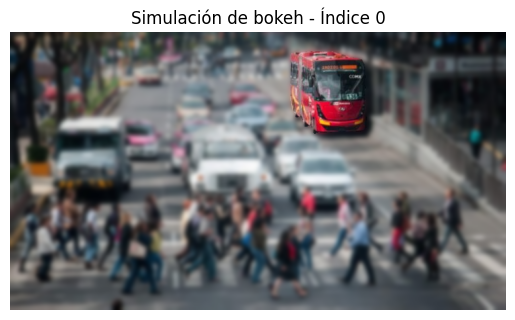

In [ ]:
def desenfocar_fondo(imagen, mask):
    fondo = cv2.GaussianBlur(imagen, (21, 21), 0)
    return np.where(mask[..., None] == 1, imagen, fondo)

imagen_bokeh = desenfocar_fondo(image, binary_mask)

plt.imshow(imagen_bokeh)
plt.title(f"Simulación de bokeh - Índice {indice}")
plt.axis('off')
plt.show()